# PLIP Model Testing with Enhanced Pre-processing and FAISS Integration

In this notebook, we will implement a Content-Based Image Retrieval (CBIR) system using the PLIP (CLIP-based) model. We will follow these steps:

1. **Import the PubMed Dataset**
2. **Pre-process Images**: Resize and enhance images without cropping.
3. **Generate Image Embeddings**
4. **Integrate FAISS for Efficient Retrieval**
5. **Test the Retrieval System**

Let's begin!

#### Import Libraries

In [1]:
# Import necessary libraries
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image, ImageEnhance
import numpy as np
from tqdm import tqdm

## Step 1: Import the PubMed Dataset
We will load the captions and UUIDs from the PubMed dataset. We are only concerned with the images and their identifiers.

In [2]:
# Define path for PubMed dataset
pubmed_path = './pubmed_set/captions.json'

# Function to load JSON data into a DataFrame
def load_captions(json_path):
    with open(json_path, 'r') as file:
        data = json.load(file)
    # Convert to DataFrame and transpose for better readability
    df = pd.DataFrame(data).T
    return df

# Load the PubMed dataset
pubmed_df = load_captions(pubmed_path)

# Retrieve the captions and UUIDs from the DataFrame
pubmed_captions = pubmed_df['caption'].tolist()
pubmed_uuids = pubmed_df['uuid'].tolist()

# Display the first few entries
pubmed_df.head()

,caption,uuid
0,"ER expression in tumor tissue. IHC staining, o...",3f93c716-8fc9-42e9-bc29-bec52a51ab4b
1,Nuclear expression of TS (brown) in a colon ca...,9fcdf1e1-139c-4b63-bf1a-79d83c71f41a
2,Nuclear expression of E2F1 (brown) in a colon ...,00f1ad7a-f4b0-4938-b874-089d40a123ce
3,Cytoplasmic immunoexpression of PD-L1 in oral ...,9d3aef30-7c8b-4b78-9acf-ec523f952650
4,Nuclear and perinuclear immunoexpression of Fo...,b317d529-3626-49fc-9282-e4f28cf3d1cb


## Step 2: Pre-process Images
We will:

- **Resize** all images to a uniform size (e.g., 224x224 pixels).
- **Enhance** images using contrast enhancement.
- **Save** the processed images in a separate directory to preserve the original data.

In [3]:
import os
import shutil
from PIL import Image, ImageEnhance
from tqdm import tqdm

# Directory to save processed images
processed_image_dir = './pubmed_set/processed_images/'

# Clear the processed images folder before pre-processing
if os.path.exists(processed_image_dir):
    shutil.rmtree(processed_image_dir)
os.makedirs(processed_image_dir, exist_ok=True)

# Initialize a list to store UUIDs of images that fail to process
error_uuids = []
error_count = 0  # Variable to keep count of errors

# Function to resize and enhance images
def preprocess_image(image_path, output_path, uuid, size=(224, 224), contrast_factor=1.5):
    global error_count  # Declare error_count as global to modify it inside the function
    try:
        img = Image.open(image_path).convert("RGB")
        # Resize image
        img = img.resize(size)
        # Enhance contrast
        enhancer = ImageEnhance.Contrast(img)
        img = enhancer.enhance(contrast_factor)
        # Save processed image
        img.save(output_path)
    except Exception as e:
        # Increment error count and store UUID without printing the error
        error_count += 1
        error_uuids.append(uuid)

# Pre-process images with a progress bar
image_dir = './pubmed_set/images/'
for uuid in tqdm(pubmed_uuids, desc="Processing Images"):
    input_path = os.path.join(image_dir, uuid + '.jpg')
    output_path = os.path.join(processed_image_dir, uuid + '.jpg')
    preprocess_image(input_path, output_path, uuid)

print(f"Total errors encountered: {error_count}")

# Remove any images in the processed images folder that correspond to error UUIDs
for uuid in error_uuids:
    processed_image_path = os.path.join(processed_image_dir, uuid + '.jpg')
    if os.path.exists(processed_image_path):
        os.remove(processed_image_path)

Processing Images: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3309/3309 [00:16<00:00, 194.67it/s]

Total errors encountered: 37


In [4]:
# Exclude error UUIDs from the lists
processed_uuids = [uuid for uuid in pubmed_uuids if uuid not in error_uuids]
processed_captions = [caption for uuid, caption in zip(pubmed_uuids, pubmed_captions) if uuid not in error_uuids]
processed_image_paths = [os.path.join(processed_image_dir, uuid + '.jpg') for uuid in processed_uuids]

Let's verify that the images have been processed and saved correctly by displaying a sample image.

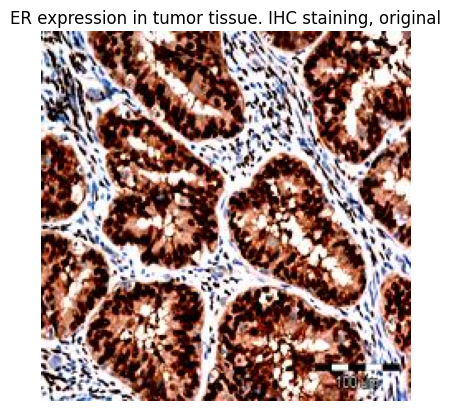

In [5]:
# Select a sample image
sample_uuid = pubmed_uuids[0]
sample_image_path = os.path.join(processed_image_dir, sample_uuid + '.jpg')

# Read and display the sample image
img = mpimg.imread(sample_image_path)
plt.imshow(img)
plt.title(pubmed_captions[0])
plt.axis('off')
plt.show()

## Step 3: Generate Image Embeddings
We will use the PLIP model (based on CLIP) to generate embeddings for the pre-processed images.

In [6]:
import torch
from transformers import CLIPModel, CLIPProcessor
from datasets import Dataset
from torch.utils.data import DataLoader

In [7]:
from typing import List

class PLIP:
    def __init__(self, model_name, device=None):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.model_name = model_name
        self.model, self.processor = self._load_model(model_name)
        self.model = self.model.to(self.device)
    
    def _load_model(self, name: str):
        model = CLIPModel.from_pretrained(name)
        processor = CLIPProcessor.from_pretrained(name)
        return model, processor

    def encode_images(self, image_paths: List[str], batch_size: int = 32):
        dataset = Dataset.from_dict({'image': image_paths})
        dataset.set_transform(lambda examples: self.processor( images=[Image.open(img_path).convert('RGB') for img_path in examples['image']], return_tensors='pt'))
        dataloader = DataLoader(dataset, batch_size=batch_size)

        image_embeddings = []
        for batch in tqdm(dataloader, desc="Generating Embeddings"):
            batch = {k: v.to(self.device) for k, v in batch.items()}
            with torch.no_grad():
                embeddings = self.model.get_image_features(**batch)
            image_embeddings.append(embeddings.cpu())
        return torch.cat(image_embeddings)

In [8]:
# Get list of processed image paths using processed_uuids
processed_image_paths = [os.path.join(processed_image_dir, uuid + '.jpg') for uuid in processed_uuids]

# Initialize PLIP model
plip_model = PLIP(model_name="openai/clip-vit-base-patch32")

# Generate embeddings using the updated list
image_embeddings = plip_model.encode_images(processed_image_paths)

/Users/mohammedkhodorfirasal-tal/Documents/Professional/Work/Fellowship - Novartis/Data/venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Generating Embeddings: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [01:06<00:00,  1.54it/s]


## Step 4: Integrate FAISS for Efficient Retrieval
We will use FAISS to index the image embeddings for efficient similarity search.

In [9]:
# Install FAISS if not already installed
# Uncomment the following line if FAISS is not installed
# !pip install faiss-cpu

import faiss

In [10]:
# Convert embeddings to NumPy array
embeddings_np = image_embeddings.numpy().astype('float32')

# Normalize embeddings (if using cosine similarity)
faiss.normalize_L2(embeddings_np)

# Build FAISS index
index = faiss.IndexFlatIP(embeddings_np.shape[1])  # Inner product for cosine similarity
index.add(embeddings_np)

print(f"FAISS index contains {index.ntotal} vectors.")

FAISS index contains 3272 vectors.


In [11]:
# After generating embeddings
# Convert embeddings to NumPy array
embeddings_np = image_embeddings.numpy().astype('float32')

# Save embeddings to a NumPy file
np.save('image_embeddings.npy', embeddings_np)

# Save the processed image paths and captions
np.save('processed_image_paths.npy', processed_image_paths)
np.save('processed_captions.npy', processed_captions)

## Step 5: Test the Retrieval System
We will select a query image and retrieve the top K most similar images based on cosine similarity.

In [ ]:
def retrieve_similar_images(query_embedding, index, k=5):
    # Normalize query embedding
    query_embedding = query_embedding.numpy().astype('float32')
    faiss.normalize_L2(query_embedding)

    # Perform search
    distances, indices = index.search(query_embedding, k)
    return distances[0], indices[0]

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# Select a random query image from the processed list
query_idx = random.randint(0, len(processed_image_paths) - 1)
query_image_path = processed_image_paths[query_idx]
query_caption = processed_captions[query_idx]

# Get query embedding
query_embedding = image_embeddings[query_idx].unsqueeze(0)

# Retrieve similar images
k = 5
distances, indices = index.search(query_embedding.numpy().astype('float32'), k)

# Display query image
print("Query Image:")
display_image = Image.open(query_image_path)
plt.imshow(display_image)
plt.title(f"Query Image\nCaption: {query_caption}")
plt.axis('off')
plt.show()
plt.close()             # Add this line to close the plot
display_image.close()   # Add this line to close the image

# Display retrieved images
print(f"Top {k} similar images:")
for rank, idx in enumerate(indices[0]):
    retrieved_image_path = processed_image_paths[idx]
    retrieved_caption = processed_captions[idx]
    similarity = distances[0][rank]
    
    # Display image
    retrieved_image = Image.open(retrieved_image_path)
    plt.imshow(retrieved_image)
    plt.title(f"Rank {rank + 1} - Similarity: {similarity:.4f}\nCaption: {retrieved_caption}")
    plt.axis('off')
    plt.show()
    plt.close()              # Close the plot
    retrieved_image.close()  # Close the image

### Analysis of Results
- **Check if the retrieved images are biologically relevant to the query image.**
- **Observe the similarity scores to assess retrieval quality.**
- **Note any improvements compared to previous runs without FAISS and standardized pre-processing.**

## Next Steps

- **Fine-tune the pre-processing parameters (e.g., image size, contrast factor) to further improve retrieval accuracy.**
- **Experiment with different CLIP models or fine-tune the existing model on a subset of your data.**
- **Consider incorporating textual information (captions) into the retrieval system for multimodal retrieval.**